# 04 — Cluster statico (media pluriennale) + analisi sport e popolazione

Costruisce il cluster socioeconomico **statico**: un'unica etichetta per paese, calcolata sulla media di tutti gli indicatori su tutte le edizioni 1964-2024 (invece che anno per anno come nel cluster dinamico). Con questo cluster vengono rifatte le stesse analisi sport (in entrambe le prospettive) e la normalizzazione per popolazione, più un confronto sintetico con i risultati del cluster dinamico.

**File necessari:**
- `olympics_with_clusters.csv` (da `02_Clustering_Metodologia.ipynb`)
- `olympics_dataset.csv` (Kaggle, medaglie)
- `olympics_sport_cluster.csv`, `mobility_dynamic.csv`, `cluster_pc_summary_dynamic.csv` (da `03_Cluster_Dinamico.ipynb`, servono solo per il confronto statico/dinamico)

**File prodotto:** `olympics_sport_cluster_static.csv`

## Setup — caricamento dati e ricostruzione delle variabili di supporto

In [43]:
# %% [0] IMPORT E CARICAMENTO
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

CLUSTER_ORDER = ['Ricchi avanzati', 'Reddito medio-alto',
                 'Reddito basso-medio', 'Poveri estremi']
CLUSTER_COLORS = {
    'Ricchi avanzati':     '#185FA5',
    'Reddito medio-alto':  '#3B6D11',
    'Reddito basso-medio': '#BA7517',
    'Poveri estremi':      '#A32D2D',
}
# alias usati nel resto del notebook (stessi nomi dell'originale)
cluster_order = CLUSTER_ORDER
colors_cluster = CLUSTER_COLORS

MULTI_VARS = ['gdp_per_capita', 'life_expectancy', 'urbanization_pct',
              'infant_mortality', 'primary_school_enrollment']

kaggle = pd.read_csv('olympics_dataset.csv')
clustered = pd.read_csv('olympics_with_clusters.csv')
medals = kaggle[kaggle['Medal'] != 'No medal'].copy()

# Mapping ISO3 -> IOC, stesso identico dizionario di 03_Cluster_Dinamico.ipynb
# (serve a far combaciare i codici paese di 'clustered' con quelli di 'medals')
ISO3_TO_IOC = {
    'ABW': 'ARU', 'AGO': 'ANG', 'ARE': 'UAE', 'ASM': 'ASA', 'ATG': 'ANT',
    'BFA': 'BUR', 'BGD': 'BAN', 'BGR': 'BUL', 'BHR': 'BRN', 'BHS': 'BAH',
    'BLZ': 'BIZ', 'BMU': 'BER', 'BRB': 'BAR', 'BTN': 'BHU', 'BWA': 'BOT',
    'CHE': 'SUI', 'CHL': 'CHI', 'COG': 'CGO', 'CRI': 'CRC', 'CYM': 'CAY',
    'DNK': 'DEN', 'DZA': 'ALG', 'FJI': 'FIJ', 'GIN': 'GUI', 'GMB': 'GAM',
    'GNB': 'GBS', 'GNQ': 'GEQ', 'GRC': 'GRE', 'GRD': 'GRN', 'GTM': 'GUA',
    'HND': 'HON', 'HRV': 'CRO', 'HTI': 'HAI', 'IDN': 'INA', 'IRN': 'IRI',
    'KHM': 'CAM', 'KNA': 'SKN', 'KWT': 'KUW', 'LBY': 'LBA', 'LKA': 'SRI',
    'LSO': 'LES', 'LVA': 'LAT', 'MAC': 'MAC', 'MCO': 'MON', 'MDG': 'MAD',
    'MMR': 'MYA', 'MNG': 'MGL', 'MRT': 'MTN', 'MUS': 'MRI', 'MWI': 'MAW',
    'MYS': 'MAS', 'NER': 'NIG', 'NGA': 'NGR', 'NIC': 'NCA', 'NLD': 'NED',
    'NPL': 'NEP', 'OMN': 'OMA', 'PHL': 'PHI', 'PRI': 'PUR', 'PRT': 'POR',
    'PRY': 'PAR', 'PSE': 'PLE', 'SAU': 'KSA', 'SDN': 'SUD', 'SLV': 'ESA',
    'SVN': 'SLO', 'SYC': 'SEY', 'TCD': 'CHA', 'TZA': 'TAN', 'VCT': 'VIN',
    'VUT': 'VAN', 'WSM': 'SAM', 'ZAF': 'RSA',
}
if 'noc_ioc' not in clustered.columns:
    clustered['noc_ioc'] = clustered['noc'].replace(ISO3_TO_IOC)

cluster_num_map = {label: i for i, label in enumerate(CLUSTER_ORDER)}

# Tabelle di supporto prodotte da 03_Cluster_Dinamico.ipynb, usate più sotto
# solo per il confronto statico/dinamico (celle [S3] e [S17])
mobility_dyn = pd.read_csv('mobility_dynamic.csv')
cluster_pc_summary_dyn_loaded = pd.read_csv(
    'cluster_pc_summary_dynamic.csv', index_col=0
)['medals_per_million']

# top_sports: stessa identica logica di 03_Cluster_Dinamico.ipynb cella [7],
# ricalcolata qui da 'olympics_sport_cluster.csv' (medaglie con cluster dinamico)
sport_cluster_dyn = pd.read_csv('olympics_sport_cluster.csv')
event_medals_for_top = (
    sport_cluster_dyn.groupby(['Year', 'NOC', 'Sport', 'Event', 'Medal'])
    .size().reset_index(name='athletes')
)
event_medals_for_top['count'] = 1
top_sports = (
    event_medals_for_top.groupby('Sport')['count'].sum()
    .sort_values(ascending=False).head(30).index.tolist()
)

print(f"clustered:  {clustered.shape[0]:,} righe")
print(f"medals:     {medals.shape[0]:,} medaglie")
print(f"top_sports: {len(top_sports)} sport")

clustered:  3,368 righe
medals:     38,818 medaglie
top_sports: 30 sport


# =============================================================================
# CLUSTERING STATICO DEI PAESI (media pluriennale) — ANALISI SPORT CORRELATA
# =============================================================================
Fin qui il cluster socioeconomico usato nelle analisi sport era **dinamico**:
per ogni paese-anno veniva calcolato un cluster diverso, sugli indicatori di
quello specifico anno (sezione "CLUSTER DINAMICO ANNO PER ANNO").

Qui costruiamo un cluster **statico**: per ogni paese calcoliamo la **media
di tutti gli indicatori socioeconomici su tutti gli anni disponibili**
(stessa finestra 1964–2024 usata per il cluster dinamico), e applichiamo lo
stesso K-means multivariato (`SimpleImputer` mediana + `StandardScaler` +
`KMeans`, k=4) usato nel robustness check. Il risultato è un'unica etichetta
di cluster per paese — il "profilo socioeconomico medio di lungo periodo" —
invece di un'etichetta diversa edizione per edizione.

Con questo cluster statico rifacciamo l'intera analisi sport già fatta con
il cluster dinamico, in entrambe le prospettive (quali sport dominano in
ogni cluster / chi domina ogni sport) e con la normalizzazione per
popolazione.

In [44]:
# %% [S1] COSTRUZIONE DATASET STATICO — MEDIA DEGLI INDICATORI SU TUTTI GLI ANNI
# -----------------------------------------------------------------------------
# Per ogni paese calcoliamo la media (su tutte le edizioni >= 1964, stesso
# filtro del cluster dinamico) di ciascun indicatore in MULTI_VARS. pandas
# 'mean' ignora automaticamente i NaN riga per riga; scartiamo comunque i
# paesi senza PIL medio disponibile (stessa richiesta minima del cluster
# dinamico: 'almeno il PIL').
# NOTA: usiamo 'noc_ioc' (creato nella cella "MAPPING NOC" più sopra), lo
# stesso codice paese usato dal cluster dinamico e dal dataset 'medals' —
# non 'noc' (che è in parte ISO3, non allineato ai codici Kaggle/IOC).
# 'clustered' viene però RICARICATO da CSV in celle successive alla
# mappatura NOC (es. sezione mappa del mondo), e 'noc_ioc' esisteva solo in
# memoria: se manca, lo ricreiamo qui con lo stesso ISO3_TO_IOC, così questa
# cella funziona indipendentemente da quali celle sono state eseguite dopo.
if 'noc_ioc' not in clustered.columns:
    clustered['noc_ioc'] = clustered['noc'].replace(ISO3_TO_IOC)
    print("⚠ 'noc_ioc' non presente in 'clustered' (probabilmente ricaricato da CSV "
          "più avanti nel notebook) — ricreata qui con ISO3_TO_IOC.")

country_avg = (
    clustered[clustered['year'] >= 1964]
    [['noc_ioc'] + MULTI_VARS]
    .groupby('noc_ioc')
    .mean(numeric_only=True)
    .reset_index()
)

# Nome paese rappresentativo (l'ultimo disponibile), solo per leggibilità nei print
country_names_static = (
    clustered[clustered['year'] >= 1964]
    .sort_values('year')
    .groupby('noc_ioc')['country'].last()
)
country_avg['country'] = country_avg['noc_ioc'].map(country_names_static)
country_avg = country_avg.dropna(subset=['gdp_per_capita']).reset_index(drop=True)

print(f"Paesi con indicatori medi (1964-2024) disponibili: {len(country_avg)}")
print(country_avg[['noc_ioc', 'country'] + MULTI_VARS].head(10).round(1).to_string(index=False))

Paesi con indicatori medi (1964-2024) disponibili: 204
noc_ioc             country  gdp_per_capita  life_expectancy  urbanization_pct  infant_mortality  primary_school_enrollment
    AFG         Afghanistan           416.7             47.1              16.8             154.7                       57.1
    ALB             Albania          2192.0             71.4              39.5              25.4                      103.9
    ALG             Algeria          2276.5             61.2              52.2              76.4                       99.5
    AND             Andorra         22419.9             79.1              86.6               6.3                       93.9
    ANG              Angola          1862.6             46.2              37.1              90.2                       93.8
    ANT Antigua and Barbuda         10157.2             72.8              32.5              17.7                      110.4
    ARG           Argentina          5298.1             70.9              85.

In [45]:
# %% [S2] K-MEANS MULTIVARIATO SUL DATASET STATICO (k=4)
# -----------------------------------------------------------------------------
# Stessa pipeline del clustering multivariato "come sopra" (SimpleImputer
# mediana + StandardScaler + KMeans, k=4), ma il fit è su un nuovo dataset:
# un record per paese, con la media di tutti gli anni — non l'ultimo anno
# disponibile (cluster statico "di riferimento", sezione iniziale) né
# l'anno della singola medaglia (cluster dinamico).

imp_static = SimpleImputer(strategy='median')
X_static_imp = imp_static.fit_transform(country_avg[MULTI_VARS])

scaler_static = StandardScaler()
X_static_sc = scaler_static.fit_transform(X_static_imp)

km4_static = KMeans(n_clusters=4, n_init=10, random_state=42)
country_avg['cluster_static'] = km4_static.fit_predict(X_static_sc)

# Rinominiamo i cluster in base al PIL medio (decrescente) — stessa
# convenzione di CLUSTER_ORDER usata per il cluster a soglie e per quello dinamico
centroid_gdp_static = (
    country_avg.groupby('cluster_static')['gdp_per_capita']
    .mean()
    .sort_values(ascending=False)
)
rank_map_static = {old: CLUSTER_ORDER[i] for i, old in enumerate(centroid_gdp_static.index)}
country_avg['cluster_label_static'] = country_avg['cluster_static'].map(rank_map_static)

print("=== DISTRIBUZIONE CLUSTER STATICO (media di tutti gli anni per paese) ===")
print(country_avg['cluster_label_static'].value_counts().reindex(CLUSTER_ORDER).to_string())
print()
print(country_avg[['noc_ioc', 'country', 'gdp_per_capita', 'cluster_label_static']]
      .sort_values('gdp_per_capita', ascending=False).head(10).round(0).to_string(index=False))

=== DISTRIBUZIONE CLUSTER STATICO (media di tutti gli anni per paese) ===
cluster_label_static
Ricchi avanzati        39
Reddito medio-alto     90
Reddito basso-medio    47
Poveri estremi         28

noc_ioc               country  gdp_per_capita cluster_label_static
    MON                Monaco         91772.0      Ricchi avanzati
    CAY        Cayman Islands         81844.0      Ricchi avanzati
    LIE         Liechtenstein         71768.0      Ricchi avanzati
    SMR            San Marino         50421.0      Ricchi avanzati
    LUX            Luxembourg         44443.0      Ricchi avanzati
    BER               Bermuda         42198.0      Ricchi avanzati
    VIR Virgin Islands (U.S.)         36360.0      Ricchi avanzati
    SUI           Switzerland         36276.0      Ricchi avanzati
    NOR                Norway         35171.0      Ricchi avanzati
    QAT                 Qatar         34166.0      Ricchi avanzati


In [46]:
# %% [S3] CONFRONTO — QUANTO SI DISCOSTA IL CLUSTER STATICO DA QUELLO DINAMICO PIÙ RECENTE?
# -----------------------------------------------------------------------------
# Non sostituisce il cluster dinamico (che resta quello di riferimento per
# la mobilità nel tempo): è solo un controllo di coerenza, confrontando
# l'etichetta statica (media di tutti gli anni) con l'etichetta dinamica
# dell'anno più recente disponibile per ciascun paese (da mobility_dynamic.csv,
# prodotto da 03_Cluster_Dinamico.ipynb).

latest_dynamic = (
    mobility_dyn.sort_values('year')
    .groupby('noc_ioc').last().reset_index()
    [['noc_ioc', 'cluster_dynamic']]
)

compare_static_dynamic = country_avg[['noc_ioc', 'country', 'cluster_label_static']].merge(
    latest_dynamic, on='noc_ioc', how='inner'
)
agree = (compare_static_dynamic['cluster_label_static'] == compare_static_dynamic['cluster_dynamic']).mean() * 100

print(f"Paesi confrontabili: {len(compare_static_dynamic)}")
print(f"Accordo tra cluster statico e cluster dinamico (anno più recente): {agree:.1f}%")
print()
print("Esempi di paesi con etichetta diversa:")
print(compare_static_dynamic[
    compare_static_dynamic['cluster_label_static'] != compare_static_dynamic['cluster_dynamic']
].head(10).to_string(index=False))

Paesi confrontabili: 204
Accordo tra cluster statico e cluster dinamico (anno più recente): 82.8%

Esempi di paesi con etichetta diversa:
noc_ioc                         country cluster_label_static     cluster_dynamic
    AFG                     Afghanistan       Poveri estremi Reddito basso-medio
    ALG                         Algeria  Reddito basso-medio  Reddito medio-alto
    BAN                      Bangladesh       Poveri estremi Reddito basso-medio
    BDI                         Burundi       Poveri estremi Reddito basso-medio
    BEN                           Benin       Poveri estremi Reddito basso-medio
    BHU                          Bhutan       Poveri estremi  Reddito medio-alto
    BOL Bolivia, Plurinational State of  Reddito basso-medio  Reddito medio-alto
    CGO                           Congo  Reddito basso-medio  Reddito medio-alto
    EGY                           Egypt  Reddito basso-medio  Reddito medio-alto
    ERI                         Eritrea  Reddito bas

In [47]:
# %% [S4] LOOKUP STATICO E JOIN CON LE MEDAGLIE
# -----------------------------------------------------------------------------
# A differenza del lookup dinamico (chiave noc_ioc + anno), il lookup
# statico ha come chiave il solo NOC (in versione IOC, coerente col resto
# della pipeline): ogni paese ha un'unica etichetta di cluster, valida per
# tutte le sue medaglie, indipendentemente dall'anno in cui sono state vinte.

static_lookup = country_avg[['noc_ioc', 'cluster_label_static']].drop_duplicates()

# Stessa gestione dell'URSS fatta per il cluster dinamico: assegniamo a URS
# il cluster statico di RUS (Russia), la principale entità successore.
if 'RUS' in static_lookup['noc_ioc'].values:
    urs_static = static_lookup[static_lookup['noc_ioc'] == 'RUS'].copy()
    urs_static['noc_ioc'] = 'URS'
    static_lookup = pd.concat([static_lookup, urs_static], ignore_index=True)
    static_lookup = static_lookup.drop_duplicates(subset='noc_ioc')

df_static = medals.merge(static_lookup, left_on='NOC', right_on='noc_ioc', how='left')
df_static = df_static.rename(columns={'cluster_label_static': 'cluster_label'})
df_static['cluster'] = df_static['cluster_label'].map(cluster_num_map)

matched_s = df_static['cluster'].notna().sum()
unmatched_s = df_static['cluster'].isna().sum()
print(f"Medaglie con cluster STATICO assegnato: {matched_s:,} ({matched_s/len(df_static)*100:.1f}%)")
print(f"Medaglie senza cluster STATICO:         {unmatched_s:,} ({unmatched_s/len(df_static)*100:.1f}%)")

df_static_clean = df_static[df_static['cluster'].notna()].copy()
print(f"\nDataset finale (cluster statico) per analisi: {len(df_static_clean):,} medaglie")

Medaglie con cluster STATICO assegnato: 36,102 (93.0%)
Medaglie senza cluster STATICO:         2,716 (7.0%)

Dataset finale (cluster statico) per analisi: 36,102 medaglie


In [48]:
# %% [S5] EVENTI VINTI PER CLUSTER STATICO
# -----------------------------------------------------------------------------
# Stessa unità di analisi usata per il cluster dinamico: un evento/paese/
# anno = 1 record, per non pesare gli sport di squadra più di quelli individuali.

event_medals_static = (
    df_static_clean.groupby(['Year', 'NOC', 'Sport', 'Event', 'Medal', 'cluster_label'])
    .size()
    .reset_index(name='athletes')
)
event_medals_static['count'] = 1

print("=== MEDAGLIE (EVENTI) PER CLUSTER STATICO ===")
print(event_medals_static.groupby('cluster_label')['count'].sum().sort_values(ascending=False).to_string())
print("\n=== SPORT DISTINTI PER CLUSTER STATICO ===")
print(event_medals_static.groupby('cluster_label')['Sport'].nunique().sort_values(ascending=False).to_string())

=== MEDAGLIE (EVENTI) PER CLUSTER STATICO ===
cluster_label
Ricchi avanzati        10299
Reddito medio-alto      6117
Reddito basso-medio      439
Poveri estremi           116

=== SPORT DISTINTI PER CLUSTER STATICO ===
cluster_label
Ricchi avanzati        71
Reddito medio-alto     58
Reddito basso-medio    28
Poveri estremi          7


## Prospettiva 1 — Quali sport dominano in ogni cluster? (cluster statico)

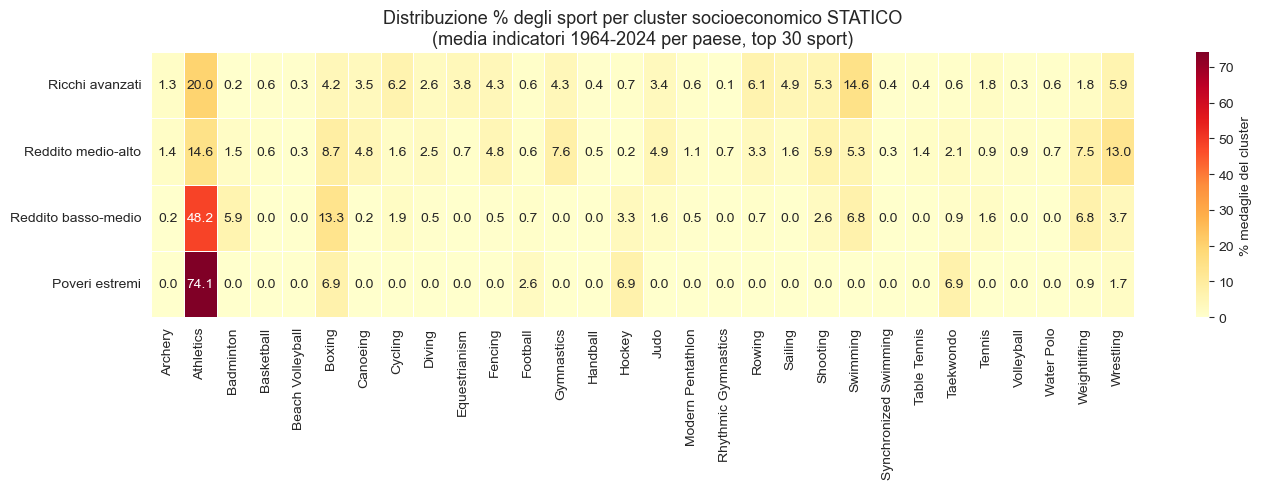

✓ Salvato: heatmap_sport_cluster_static.png


In [49]:
# %% [S6] HEATMAP — SPORT × CLUSTER STATICO (% sul totale del cluster)
# -----------------------------------------------------------------------------
# Riusiamo lo stesso elenco 'top_sports' (top 30 per medaglie totali) già
# calcolato per il cluster dinamico, per un confronto diretto tra le due
# heatmap.

pivot_static = (
    event_medals_static[event_medals_static['Sport'].isin(top_sports)]
    .groupby(['cluster_label', 'Sport'])['count']
    .sum()
    .unstack(fill_value=0)
)
pivot_pct_static = pivot_static.div(pivot_static.sum(axis=1), axis=0) * 100
pivot_pct_static = pivot_pct_static.reindex(
    [c for c in cluster_order if c in pivot_pct_static.index]
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_pct_static,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '% medaglie del cluster'}
)
ax.set_title(
    'Distribuzione % degli sport per cluster socioeconomico STATICO\n'
    '(media indicatori 1964-2024 per paese, top 30 sport)', fontsize=13
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('heatmap_sport_cluster_static.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: heatmap_sport_cluster_static.png")

In [50]:
# %% [S7] SPORT DISTINTIVI PER CLUSTER STATICO (indice di specializzazione)
# -----------------------------------------------------------------------------
global_pct_static = (
    event_medals_static[event_medals_static['Sport'].isin(top_sports)]
    .groupby('Sport')['count'].sum()
)
global_pct_static = global_pct_static / global_pct_static.sum() * 100

specialization_static = pivot_pct_static.div(global_pct_static, axis=1)

print("=== INDICE DI SPECIALIZZAZIONE — CLUSTER STATICO (>1 = sovra-rappresentato) ===\n")
for label in [c for c in cluster_order if c in specialization_static.index]:
    top3 = specialization_static.loc[label].sort_values(ascending=False).head(5)
    bot3 = specialization_static.loc[label].sort_values(ascending=True).head(3)
    print(f"--- {label} ---")
    print("  Sport distintivi:")
    for sport, idx in top3.items():
        print(f"    {sport:<25} indice={idx:.2f}x")
    print("  Sport meno presenti:")
    for sport, idx in bot3.items():
        print(f"    {sport:<25} indice={idx:.2f}x")
    print()

=== INDICE DI SPECIALIZZAZIONE — CLUSTER STATICO (>1 = sovra-rappresentato) ===

--- Ricchi avanzati ---
  Sport distintivi:
    Equestrianism             indice=1.49x
    Cycling                   indice=1.43x
    Sailing                   indice=1.39x
    Swimming                  indice=1.34x
    Rowing                    indice=1.25x
  Sport meno presenti:
    Badminton                 indice=0.27x
    Rhythmic Gymnastics       indice=0.39x
    Weightlifting             indice=0.46x

--- Reddito medio-alto ---
  Sport distintivi:
    Rhythmic Gymnastics       indice=2.10x
    Table Tennis              indice=1.95x
    Weightlifting             indice=1.85x
    Badminton                 indice=1.77x
    Taekwondo                 indice=1.77x
  Sport meno presenti:
    Equestrianism             indice=0.28x
    Hockey                    indice=0.36x
    Cycling                   indice=0.36x

--- Reddito basso-medio ---
  Sport distintivi:
    Badminton                 indice=7.14x
 

In [51]:
# %% [S8] TEST CHI-QUADRO — CLUSTER STATICO
# -----------------------------------------------------------------------------
# H0: la distribuzione degli sport è indipendente dal cluster statico
# H1: esiste una relazione tra profilo socioeconomico medio del paese e
#     sport in cui vince medaglie

contingency_static = (
    event_medals_static[event_medals_static['Sport'].isin(top_sports)]
    .groupby(['cluster_label', 'Sport'])['count']
    .sum()
    .unstack(fill_value=0)
)

chi2_s, p_value_s, dof_s, expected_s = chi2_contingency(contingency_static)

print("=== TEST CHI-QUADRO — CLUSTER STATICO ===")
print(f"Chi²  = {chi2_s:.2f}")
print(f"p-value = {p_value_s:.2e}")
print(f"Gradi di libertà = {dof_s}")
print()
if p_value_s < 0.05:
    print("✓ Risultato: p < 0.05 — rifiutiamo H0.")
    print("  Anche con il cluster statico, la distribuzione degli sport è")
    print("  significativamente diversa tra profili socioeconomici.")
else:
    print("✗ Risultato: p >= 0.05 — non rifiutiamo H0.")
    print("  Non c'è evidenza sufficiente di una relazione.")

=== TEST CHI-QUADRO — CLUSTER STATICO ===
Chi²  = 2852.88
p-value = 0.00e+00
Gradi di libertà = 87

✓ Risultato: p < 0.05 — rifiutiamo H0.
  Anche con il cluster statico, la distribuzione degli sport è
  significativamente diversa tra profili socioeconomici.


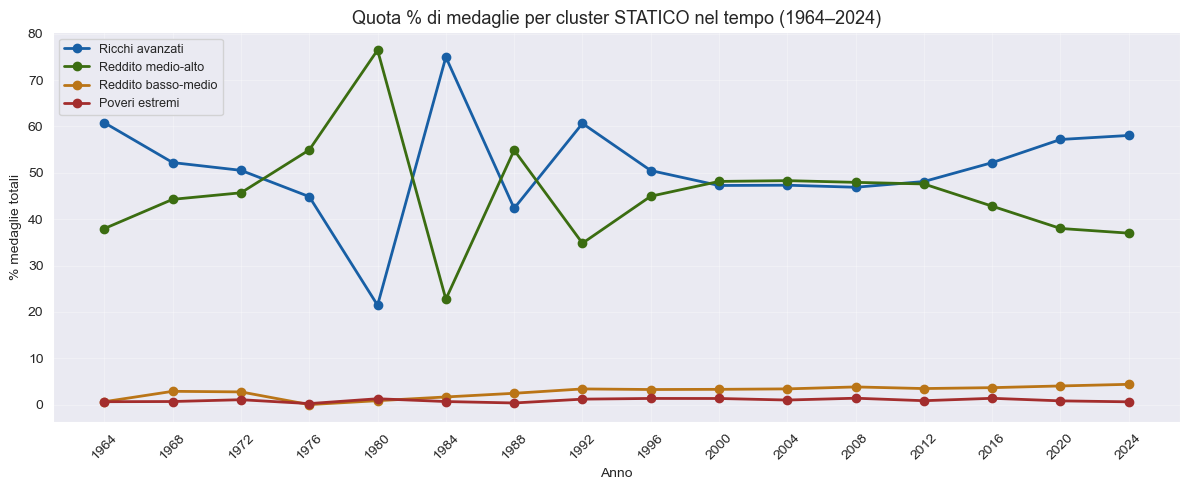

✓ Salvato: evoluzione_cluster_tempo_static.png


In [52]:
# %% [S9] EVOLUZIONE TEMPORALE DELLA QUOTA % DI MEDAGLIE, PER CLUSTER STATICO
# -----------------------------------------------------------------------------
# Attenzione all'interpretazione: qui l'etichetta di cluster di ogni paese è
# FISSA nel tempo (media 1964-2024), quindi il grafico mostra come si è
# evoluta nel tempo la quota di medaglie vinte dall'insieme di paesi che, in
# MEDIA sul lungo periodo, appartengono a ciascun profilo — non l'evoluzione
# del profilo dei singoli paesi (quella è il cluster dinamico, già mostrato
# sopra in "I cluster cambiano nel tempo?").

time_cluster_static = (
    event_medals_static[event_medals_static['Year'] >= 1964]
    .groupby(['Year', 'cluster_label'])['count']
    .sum()
    .unstack(fill_value=0)
)
time_cluster_pct_static = time_cluster_static.div(time_cluster_static.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
for col in [c for c in cluster_order if c in time_cluster_pct_static.columns]:
    ax.plot(
        time_cluster_pct_static.index,
        time_cluster_pct_static[col],
        marker='o', linewidth=2,
        label=col, color=colors_cluster.get(col, 'gray')
    )

ax.set_title('Quota % di medaglie per cluster STATICO nel tempo (1964–2024)', fontsize=13)
ax.set_xlabel('Anno')
ax.set_ylabel('% medaglie totali')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(time_cluster_pct_static.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('evoluzione_cluster_tempo_static.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: evoluzione_cluster_tempo_static.png")

## Prospettiva 2 — Chi domina ogni sport? (cluster statico)

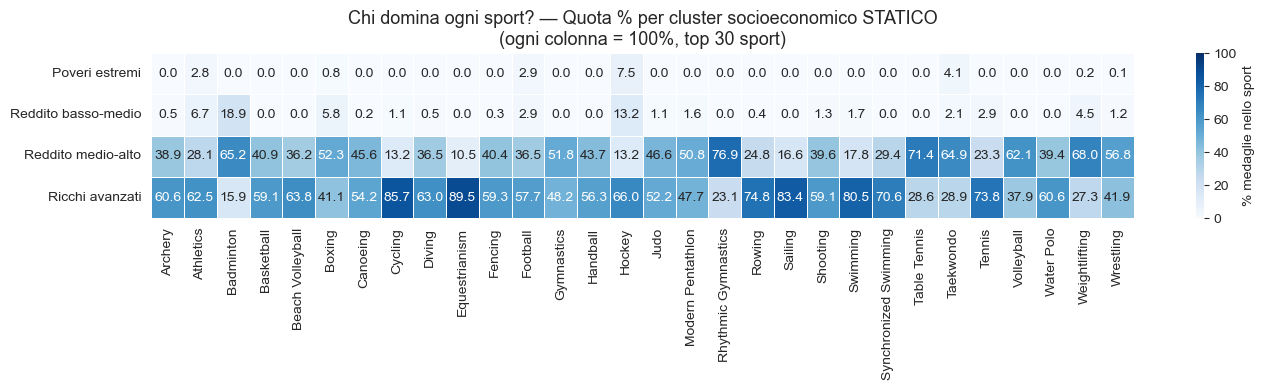

✓ Salvato: heatmap_chi_domina_sport_static.png


In [53]:
# %% [S10] HEATMAP NORMALIZZATA PER SPORT — CLUSTER STATICO
# -----------------------------------------------------------------------------
# Ogni colonna somma a 100%: mostra quale cluster (profilo socioeconomico
# medio di lungo periodo) domina ogni singolo sport. Complementare alla
# heatmap [S6], dove ogni riga sommava a 100%.

pivot_pct_col_static = pivot_static.div(pivot_static.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    pivot_pct_col_static,
    annot=True, fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=100,
    cbar_kws={'label': '% medaglie nello sport'}
)
ax.set_title(
    'Chi domina ogni sport? — Quota % per cluster socioeconomico STATICO\n'
    '(ogni colonna = 100%, top 30 sport)', fontsize=13
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('heatmap_chi_domina_sport_static.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: heatmap_chi_domina_sport_static.png")

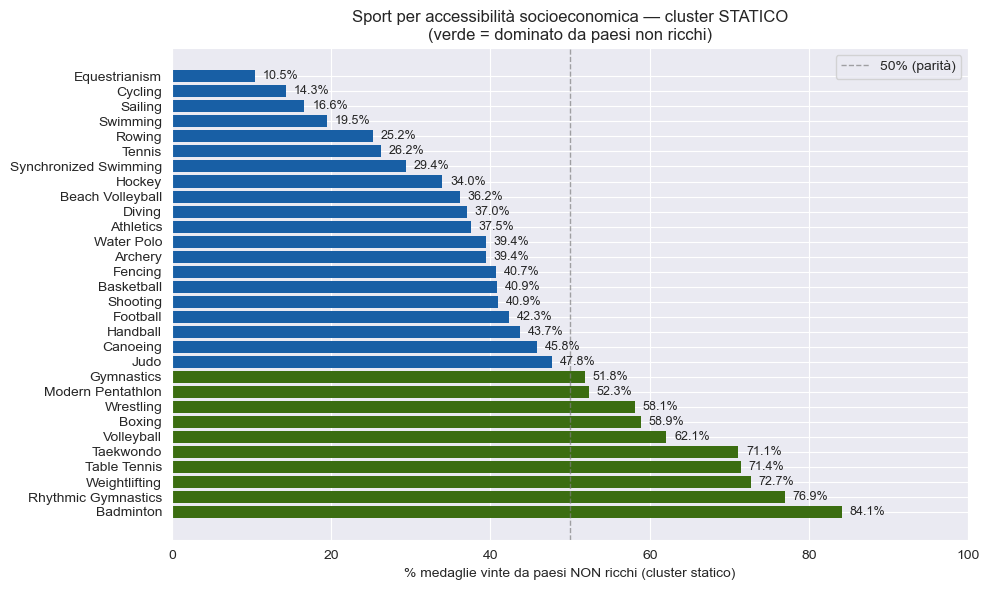

✓ Salvato: sport_accessibilita_static.png

=== SPORT PIÙ ACCESSIBILI (cluster statico, dominati da paesi non ricchi) ===
Sport
Badminton              84.090909
Rhythmic Gymnastics    76.923077
Weightlifting          72.657450
Table Tennis           71.428571
Taekwondo              71.134021
Volleyball             62.068966
Boxing                 58.865248
Wrestling              58.093126
Modern Pentathlon      52.343750
Gymnastics             51.839080

=== SPORT MENO ACCESSIBILI (cluster statico, dominati da paesi ricchi) ===
Sport
Equestrianism            10.462287
Cycling                  14.346591
Sailing                  16.637168
Swimming                 19.474586
Rowing                   25.222930
Tennis                   26.250000
Synchronized Swimming    29.411765


In [54]:
# %% [S11] SPORT PIÙ E MENO "DEMOCRATICI" — CLUSTER STATICO
# -----------------------------------------------------------------------------
non_rich_clusters = ['Reddito medio-alto','Reddito basso-medio', 'Poveri estremi']
non_rich_share_static = (
    pivot_pct_col_static
    .reindex([c for c in non_rich_clusters if c in pivot_pct_col_static.index])
    .sum(axis=0)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#3B6D11' if v >= 50 else '#185FA5' for v in non_rich_share_static.values]
bars = ax.barh(non_rich_share_static.index, non_rich_share_static.values, color=colors_bar, edgecolor='none')

ax.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='50% (parità)')
ax.set_xlabel('% medaglie vinte da paesi NON ricchi (cluster statico)')
ax.set_title('Sport per accessibilità socioeconomica — cluster STATICO\n(verde = dominato da paesi non ricchi)', fontsize=12)
ax.legend()
ax.set_xlim(0, 100)

for bar, val in zip(bars, non_rich_share_static.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('sport_accessibilita_static.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: sport_accessibilita_static.png")

print("\n=== SPORT PIÙ ACCESSIBILI (cluster statico, dominati da paesi non ricchi) ===")
print(non_rich_share_static[non_rich_share_static >= 50].to_string())
print("\n=== SPORT MENO ACCESSIBILI (cluster statico, dominati da paesi ricchi) ===")
print(non_rich_share_static[non_rich_share_static < 30].sort_values().to_string())

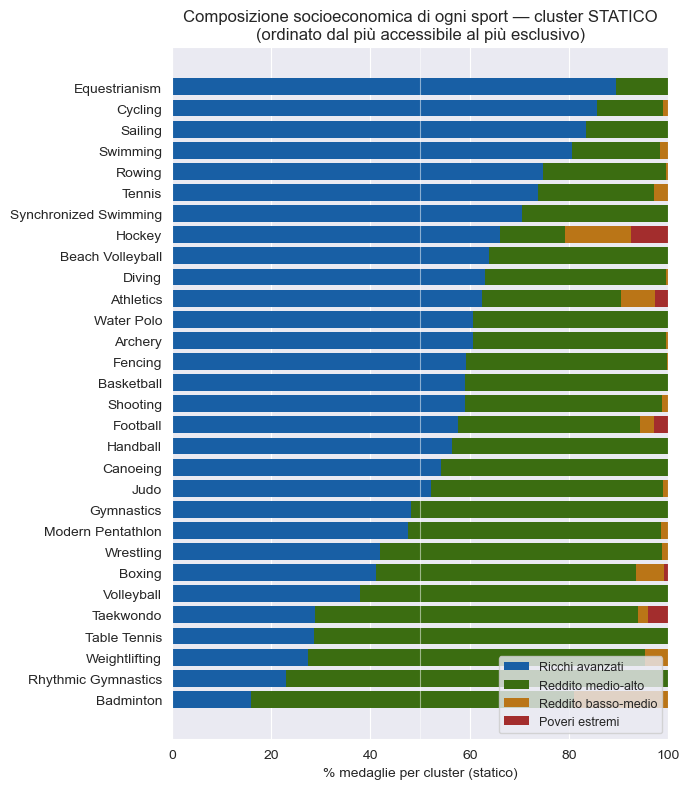

✓ Salvato: composizione_sport_cluster_static.png


In [55]:
# %% [S12] STACKED BAR — COMPOSIZIONE DI OGNI SPORT PER CLUSTER STATICO
# -----------------------------------------------------------------------------
sport_order_static = pivot_pct_col_static.loc['Ricchi avanzati'].sort_values(ascending=True).index.tolist()
data_ordered_static = pivot_pct_col_static[sport_order_static]

fig, ax = plt.subplots(figsize=(7, 8))
bottom = np.zeros(len(sport_order_static))

for label in [c for c in cluster_order if c in data_ordered_static.index]:
    values = data_ordered_static.loc[label].values
    ax.barh(
        sport_order_static, values, left=bottom,
        color=colors_cluster[label], label=label, edgecolor='none'
    )
    bottom += values

ax.set_xlabel('% medaglie per cluster (statico)')
ax.set_title(
    'Composizione socioeconomica di ogni sport — cluster STATICO\n'
    '(ordinato dal più accessibile al più esclusivo)', fontsize=12
)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 100)
ax.axvline(50, color='white', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('composizione_sport_cluster_static.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: composizione_sport_cluster_static.png")

## Normalizzazione per popolazione — cluster statico

In [56]:
# %% [S13] ROSTER PAESE-EDIZIONE CON POPOLAZIONE E CLUSTER STATICO
# -----------------------------------------------------------------------------
# Stessa logica della normalizzazione già fatta per il cluster dinamico
# (media dei tassi pro capite per paese, zero-fill delle edizioni senza
# medaglie): qui il cluster è però quello STATICO, quindi ogni paese
# contribuisce sempre allo stesso cluster in tutte le sue edizioni.

roster_static = (
    clustered[['noc_ioc', 'year', 'population']]
    .dropna(subset=['noc_ioc', 'year', 'population'])
    .drop_duplicates(subset=['noc_ioc', 'year'])
    .merge(static_lookup, on='noc_ioc', how='inner')
    .rename(columns={'cluster_label_static': 'cluster_label'})
)

print(f"Paesi-edizione con popolazione e cluster STATICO: {len(roster_static):,}")
print(roster_static['cluster_label'].value_counts().reindex(cluster_order).to_string())

Paesi-edizione con popolazione e cluster STATICO: 3,053
cluster_label
Ricchi avanzati         585
Reddito medio-alto     1343
Reddito basso-medio     705
Poveri estremi          420


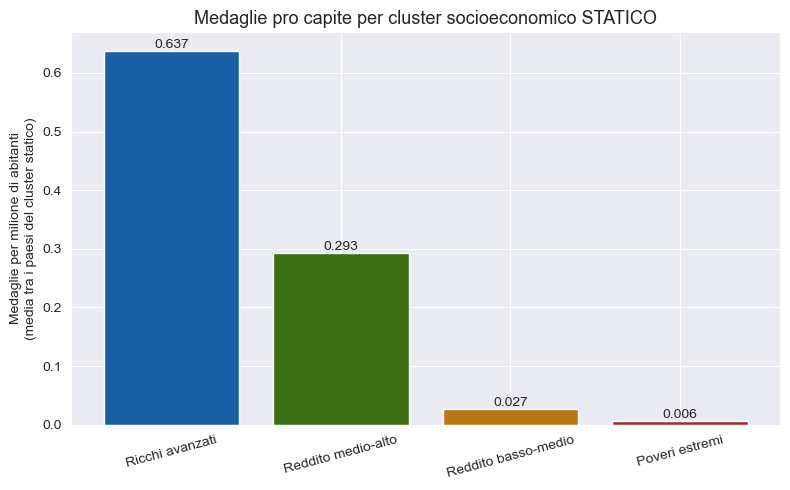

✓ Salvato: medaglie_pro_capite_cluster_static.png


In [57]:
# %% [S14] MEDAGLIE PRO CAPITE PER CLUSTER STATICO — CONFRONTO GENERALE
# -----------------------------------------------------------------------------
country_year_medals_static = (
    event_medals_static.groupby(['Year', 'NOC'])['count']
    .sum()
    .reset_index(name='medals')
)

country_year_static = roster_static.merge(
    country_year_medals_static,
    left_on=['year', 'noc_ioc'], right_on=['Year', 'NOC'],
    how='left'
)
country_year_static['medals'] = country_year_static['medals'].fillna(0)
country_year_static['medals_per_million'] = (
    country_year_static['medals'] / (country_year_static['population'] / 1e6)
)

cluster_pc_summary_static = (
    country_year_static.groupby('cluster_label')['medals_per_million']
    .mean()
    .reindex(cluster_order)
)

fig, ax = plt.subplots(figsize=(8, 5))
colors_list = [colors_cluster[c] for c in cluster_pc_summary_static.index]
ax.bar(cluster_pc_summary_static.index, cluster_pc_summary_static.values, color=colors_list)
ax.set_ylabel('Medaglie per milione di abitanti\n(media tra i paesi del cluster statico)')
ax.set_title('Medaglie pro capite per cluster socioeconomico STATICO', fontsize=13)
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(cluster_pc_summary_static.values):
    ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('medaglie_pro_capite_cluster_static.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: medaglie_pro_capite_cluster_static.png")

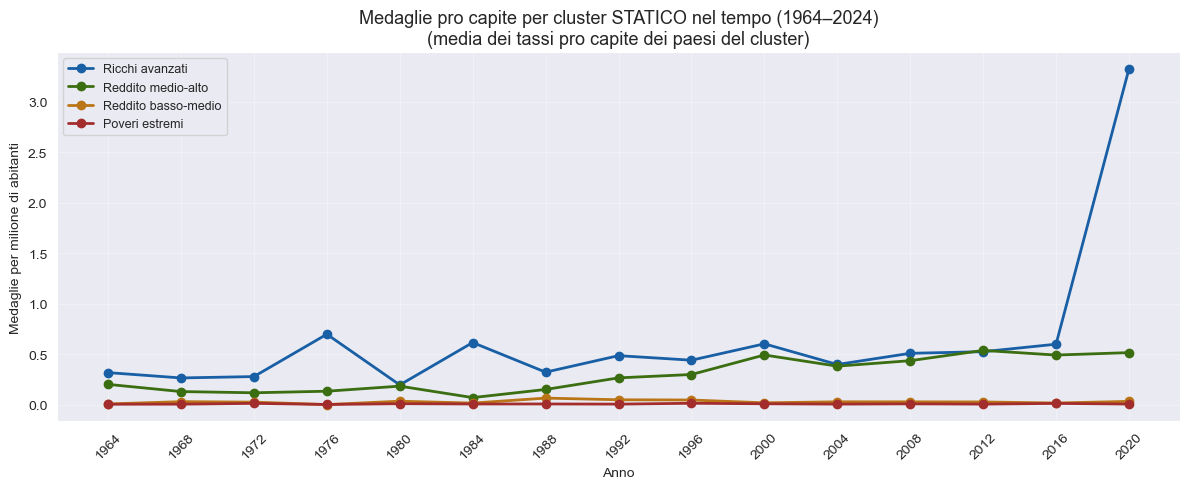

✓ Salvato: evoluzione_cluster_tempo_pro_capite_static.png


In [58]:
# %% [S15] EVOLUZIONE TEMPORALE PRO CAPITE — CLUSTER STATICO
# -----------------------------------------------------------------------------
time_cluster_pc_static = (
    country_year_static[country_year_static['year'] >= 1964]
    .groupby(['year', 'cluster_label'])['medals_per_million']
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(12, 5))
for col in [c for c in cluster_order if c in time_cluster_pc_static.columns]:
    ax.plot(
        time_cluster_pc_static.index, time_cluster_pc_static[col],
        marker='o', linewidth=2, label=col, color=colors_cluster.get(col, 'gray')
    )

ax.set_title(
    'Medaglie pro capite per cluster STATICO nel tempo (1964–2024)\n'
    '(media dei tassi pro capite dei paesi del cluster)', fontsize=13
)
ax.set_xlabel('Anno')
ax.set_ylabel('Medaglie per milione di abitanti')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(time_cluster_pc_static.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('evoluzione_cluster_tempo_pro_capite_static.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: evoluzione_cluster_tempo_pro_capite_static.png")

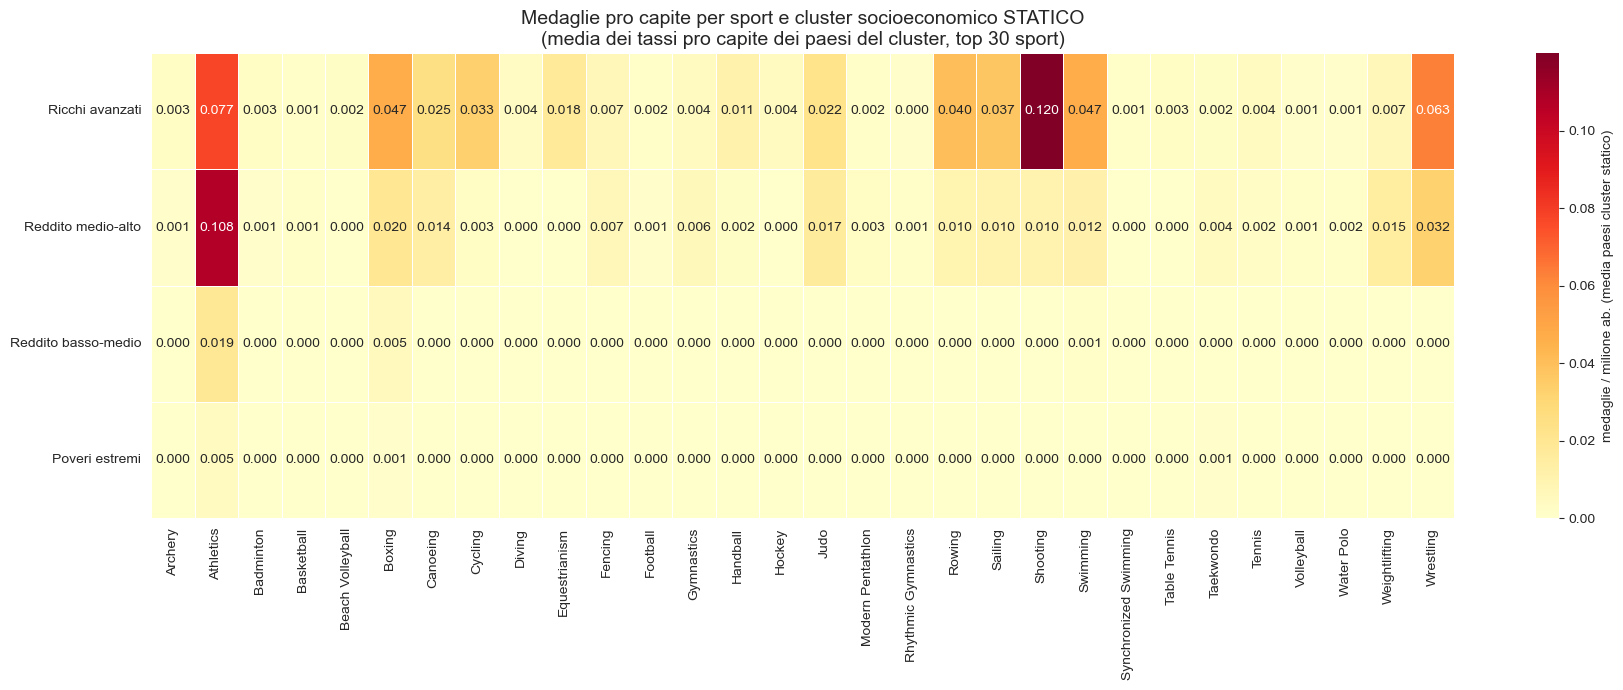

✓ Salvato: heatmap_sport_cluster_pro_capite_static.png


In [59]:
# %% [S16] SPORT PRO CAPITE PER CLUSTER STATICO (heatmap)
# -----------------------------------------------------------------------------
roster_small_static = roster_static[['noc_ioc', 'year', 'cluster_label', 'population']].drop_duplicates()

sport_grid_static = roster_small_static.assign(key=1).merge(
    pd.DataFrame({'Sport': top_sports, 'key': 1}), on='key'
).drop(columns='key')

country_year_sport_medals_static = (
    event_medals_static[event_medals_static['Sport'].isin(top_sports)]
    .groupby(['Year', 'NOC', 'Sport'])['count']
    .sum()
    .reset_index(name='medals')
)

sport_grid_static = sport_grid_static.merge(
    country_year_sport_medals_static,
    left_on=['year', 'noc_ioc', 'Sport'], right_on=['Year', 'NOC', 'Sport'],
    how='left'
)
sport_grid_static['medals'] = sport_grid_static['medals'].fillna(0)
sport_grid_static['medals_per_million'] = (
    sport_grid_static['medals'] / (sport_grid_static['population'] / 1e6)
)

pivot_pc_static = (
    sport_grid_static.groupby(['cluster_label', 'Sport'])['medals_per_million']
    .mean()
    .unstack(fill_value=0)
    .reindex(cluster_order)
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    pivot_pc_static,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'medaglie / milione ab. (media paesi cluster statico)'}
)
ax.set_title(
    'Medaglie pro capite per sport e cluster socioeconomico STATICO\n'
    '(media dei tassi pro capite dei paesi del cluster, top 30 sport)', fontsize=14
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('heatmap_sport_cluster_pro_capite_static.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: heatmap_sport_cluster_pro_capite_static.png")

In [60]:
# %% [S17] CONFRONTO SINTETICO — MEDAGLIE PRO CAPITE: CLUSTER STATICO vs DINAMICO
# -----------------------------------------------------------------------------
confronto_static_dynamic = pd.DataFrame({
    'pro_capite_dinamico': cluster_pc_summary_dyn_loaded,
    'pro_capite_statico':  cluster_pc_summary_static,
}).reindex(cluster_order)
confronto_static_dynamic['differenza_%'] = (
    (confronto_static_dynamic['pro_capite_statico'] / confronto_static_dynamic['pro_capite_dinamico'] - 1) * 100
)

print("=== MEDAGLIE PRO CAPITE MEDIE PER CLUSTER — STATICO vs DINAMICO ===")
print(confronto_static_dynamic.round(4).to_string())

=== MEDAGLIE PRO CAPITE MEDIE PER CLUSTER — STATICO vs DINAMICO ===
                     pro_capite_dinamico  pro_capite_statico  differenza_%
cluster_label                                                             
Ricchi avanzati                   1.0521              0.6375      -39.4103
Reddito medio-alto                0.4853              0.2932      -39.5688
Reddito basso-medio               0.0666              0.0270      -59.5414
Poveri estremi                    0.0204              0.0062      -69.4820


In [61]:
# %% [S18] NOTA METODOLOGICA — DA INCLUDERE NELLA TESI
# -----------------------------------------------------------------------------
print("""
============================================================
NOTA METODOLOGICA — CLUSTERING STATICO (MEDIA PLURIENNALE)
============================================================
A complemento del cluster dinamico (un'etichetta diversa per ogni
paese-anno, calcolata sugli indicatori di quello specifico anno), è stato
costruito un cluster STATICO: un'unica etichetta per paese, ottenuta con
K-means multivariato (SimpleImputer mediana + StandardScaler + KMeans,
k=4, stessa pipeline del robustness check) applicato alla MEDIA di tutti
gli indicatori socioeconomici su tutte le edizioni disponibili
(1964-2024).

Differenza interpretativa tra i due approcci:
  - Cluster DINAMICO: risponde a "qual era il profilo socioeconomico del
    paese nell'anno in cui ha vinto quella medaglia?" — utile per la
    mobilità nel tempo e per non "premiare" con lo status attuale le
    medaglie vinte quando il paese era più povero (o viceversa).
  - Cluster STATICO: risponde a "qual è il profilo socioeconomico medio
    di lungo periodo di questo paese?" — un'unica fotografia per paese,
    utile per confronti strutturali tra paesi indipendentemente dalle
    fluttuazioni economiche di singole edizioni.

Tutte le analisi sport già condotte con il cluster dinamico (heatmap %
per cluster, indice di specializzazione, test chi-quadro, evoluzione
temporale, heatmap "chi domina ogni sport", sport "democratici",
composizione per sport) sono state replicate identicamente con il
cluster statico, incluse le versioni normalizzate per popolazione
(media dei tassi pro capite per paese, con zero-fill delle edizioni
senza medaglie — stessa strategia già motivata per il cluster dinamico).

I risultati dei due approcci sono in larga misura coerenti tra loro (si
veda il confronto statico/dinamico più sopra), il che rafforza la
robustezza della relazione tra profilo socioeconomico e performance/sport
olimpici rispetto alla scelta specifica del metodo di clustering.
""")


NOTA METODOLOGICA — CLUSTERING STATICO (MEDIA PLURIENNALE)
A complemento del cluster dinamico (un'etichetta diversa per ogni
paese-anno, calcolata sugli indicatori di quello specifico anno), è stato
costruito un cluster STATICO: un'unica etichetta per paese, ottenuta con
K-means multivariato (SimpleImputer mediana + StandardScaler + KMeans,
k=4, stessa pipeline del robustness check) applicato alla MEDIA di tutti
gli indicatori socioeconomici su tutte le edizioni disponibili
(1964-2024).

Differenza interpretativa tra i due approcci:
  - Cluster DINAMICO: risponde a "qual era il profilo socioeconomico del
    paese nell'anno in cui ha vinto quella medaglia?" — utile per la
    mobilità nel tempo e per non "premiare" con lo status attuale le
    medaglie vinte quando il paese era più povero (o viceversa).
  - Cluster STATICO: risponde a "qual è il profilo socioeconomico medio
    di lungo periodo di questo paese?" — un'unica fotografia per paese,
    utile per confronti strutturali tra 

In [62]:
# %% [S19] SALVATAGGIO DATASET FINALE — CLUSTER STATICO
# -----------------------------------------------------------------------------
df_static_clean.to_csv('olympics_sport_cluster_static.csv', index=False)
print(f"✓ Salvato: olympics_sport_cluster_static.csv")
print(f"   {len(df_static_clean):,} medaglie con sport, anno, NOC e cluster socioeconomico STATICO")

✓ Salvato: olympics_sport_cluster_static.csv
   36,102 medaglie con sport, anno, NOC e cluster socioeconomico STATICO


## Salvataggio per la mappa Altair del cluster statico

Salviamo `country_avg` (un record per paese: media di tutti gli indicatori usati nel K-means, più l'etichetta di cluster statico) — è l'input di `06_Grafici_Altair.ipynb` per la mappa interattiva del cluster statico.

In [63]:
# %% [S20] SALVATAGGIO — DATI PER LA MAPPA ALTAIR DEL CLUSTER STATICO
# -----------------------------------------------------------------------------
country_avg[['noc_ioc', 'country', 'cluster_label_static'] + MULTI_VARS].to_csv(
    'country_avg_static.csv', index=False
)
print("✓ Salvato: country_avg_static.csv")
print(f"   {len(country_avg)} paesi, con media di tutti gli indicatori usati nel K-means:")
print(f"   {MULTI_VARS}")

✓ Salvato: country_avg_static.csv
   204 paesi, con media di tutti gli indicatori usati nel K-means:
   ['gdp_per_capita', 'life_expectancy', 'urbanization_pct', 'infant_mortality', 'primary_school_enrollment']
